# NaCl：从原子力到 NAC 声子谱

用随仓库提供的 NaCl 位移与力样本，扣除长程偶极力、拟合短程 FC2，再把两部分合并，交给 Phonopy 画出包含非解析修正（NAC）的声子谱。

数据来自 hiPhive 长程相互作用示例，来源与 MIT 许可证见 [数据说明](data/nacl/README.md)。力已经计算好，不需要安装 hiPhive 或运行电子结构程序。运行环境见[教程总览](index.md)。

## 1. 读取参考结构

这里先读取 8 原子的常规晶胞。数据文件中的位移结构采用 Phonopy 的超胞排序，因此后面也从同一个 Phonopy 对象取得原胞和超胞，避免两套原子顺序混用。

从 notebook 所在目录运行下面的代码即可；从仓库根目录运行时会使用同一份教学数据。日志级别只控制显示，不参与计算。

In [1]:
from pathlib import Path
import logging
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms, units
from ase.io import read
from phonopy import Phonopy
from phonopy.file_IO import parse_BORN, read_force_constants_hdf5
from phonopy.structure.atoms import PhonopyAtoms
from mlfcs import ClusterSpace, ClusterMap, ForceDataset, FitSystem, CompactForceConstants, DipoleEwald

logging.getLogger("mlfcs").setLevel(logging.WARNING)
DATA = Path("data/nacl")
if not DATA.exists():
    DATA = Path("docs/notebooks") / DATA
SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-nacl-"))
unitcell = read(DATA / "NaCl_unitcell.xyz")
print(f"常规晶胞原子数：{len(unitcell)}")

常规晶胞原子数：8


## 2. 让 Phonopy 和 MLFCS 使用同一份几何

训练数据使用常规胞的 $4\times4\times4$ 超胞，共 512 个原子。FCC 原胞矩阵把常规胞转换成含 Na、Cl 各一个原子的原胞；Phonopy 按矩阵的列给出新晶格矢量，这里采用对称的 FCC 变换。

如果换成自己的材料，需要替换结构、超胞矩阵和原胞变换，并保证训练帧的原子顺序与生成的超胞一致。

In [2]:
phonon = Phonopy(
    PhonopyAtoms(
        symbols=unitcell.get_chemical_symbols(), cell=unitcell.cell.array,
        scaled_positions=unitcell.get_scaled_positions(), masses=unitcell.get_masses(),
    ),
    supercell_matrix=np.diag([4, 4, 4]),
    primitive_matrix=[[0, .5, .5], [.5, 0, .5], [.5, .5, 0]],
)
primitive = Atoms(numbers=phonon.primitive.numbers, positions=phonon.primitive.positions,
                  cell=phonon.primitive.cell, masses=phonon.primitive.masses, pbc=True)
supercell = Atoms(numbers=phonon.supercell.numbers, positions=phonon.supercell.positions,
                  cell=phonon.supercell.cell, masses=phonon.supercell.masses, pbc=True)
print(f"原胞：{len(primitive)} 原子；超胞：{len(supercell)} 原子")

原胞：2 原子；超胞：512 原子


## 3. 选择短程模型，再连接到超胞

只恢复二阶力常数，因此 `cutoffs` 只有键 `2`。11 Å 沿用这份数据的演示设置，为短程拟合和 Ewald 局域修正提供相互作用范围，并不是已经收敛的通用截断。二阶默认最多涉及两个不同位置，无需另设体阶。

`asr=True` 让短程拟合满足刚性平移不变性。`ClusterMap` 从两份晶胞推断超胞矩阵，并保留已有原子顺序。先检查可辨识性，可以避免完成力计算后才发现超胞无法区分模型参数。

In [3]:
space = ClusterSpace(primitive, cutoffs={2: 11.0}, asr=True)
mapping = ClusterMap(space, supercell)
mapping.rank_info().require_full()
print(f"物理参数：{space.n_parameters}；ASR 自由参数：{space.n_free_parameters}")

物理参数：76；ASR 自由参数：74


## 4. 收集已经计算好的力

两帧样本包含位置和保存的力。`ForceDataset` 将位置与参考超胞比较，得到最小像位移；它不会启动 calculator。

换成自己的样本时，要保持超胞、元素及原子顺序一致，位置用 Å、力用 eV/Å。

In [4]:
structures = read(DATA / "supercells_with_forces.xyz", index=":")
dataset = ForceDataset(mapping, structures)
print(f"带力样本：{len(dataset.forces)} 帧")

带力样本：2 帧


## 5. 先扣除长程偶极力

Born 有效电荷和电子介电张量来自配套 `BORN` 文件。`parse_BORN` 按 Phonopy 原胞顺序展开电荷；Born 张量的两条轴依次是极化方向和位移方向。单位换算因子采用 ASE 的 Hartree 与 Bohr，和 MLFCS 的 eV、Å 单位一致。

`DipoleEwald` 为当前超胞计算长程谐波项。用数据集位移求出它的力，再从目标力中扣除，留下短程拟合的目标。换材料时，电学数据也必须替换；默认求和容差通常可作为起点。

In [5]:
nac = parse_BORN(phonon.primitive, filename=str(DATA / "BORN"))
nac["factor"] = units.Hartree * units.Bohr
ewald = DipoleEwald(mapping, born_charges=nac["born"], dielectric=nac["dielectric"])
short_dataset = dataset.subtract_forces(ewald.forces(dataset.displacements))
print(f"长程 FC2 的最大 ASR 残差：{ewald.asr_residual:.2e} eV/Å²")

长程 FC2 的最大 ASR 残差：3.50e-14 eV/Å²


## 6. 拟合剩余力

这个二阶模型较小，使用 `representation="raw"` 保留力方程并直接求最小二乘，不需要迭代求解参数。返回的模型只含短程 FC2。

下面的 RMSE 检查模型能否解释扣除后的力，不是声子频率的实验误差。

In [6]:
system = FitSystem(short_dataset, representation="raw")
short_model = system.solve()
print(f"短程力 RMSE：{system.rmse(short_model):.6e} eV/Å")

短程力 RMSE：1.484219e-05 eV/Å


## 7. 回加长程 FC2，交给 Phonopy

短程模型和长程输出都可转成 `CompactForceConstants` 后相加。相加时必须使用扣除阶段的同一个 mapping 和 Ewald 对象。

这里导出总 FC2 的 HDF5 文件，`threshold=0` 保留全部张量块。临时目录只用来存放中间文件；实际研究可把 `SCRATCH` 换成工作目录。Phonopy 读取时会分配完整 FC2 数组。

In [7]:
total = CompactForceConstants(short_model, mapping) + ewald.force_constants()
fc2_file = SCRATCH / "force_constants.hdf5"
total.write(fc2_file, format="phonopy", order=2, storage="hdf5", threshold=0)
phonon.force_constants = read_force_constants_hdf5(str(fc2_file))
print(f"Phonopy 已读入 {phonon.force_constants.shape[0]} 原子的总 FC2")

Phonopy 已读入 512 原子的总 FC2


## 8. 比较 NAC 前后的声子谱

沿 Γ–X–L–Γ 取样，每段 67 个点，使曲线足够平滑。先计算总 FC2 的普通傅里叶结果，再设置 `nac_params` 启用 Gonze 方法。该方法在周期 FC2 中分离并重新插值长程贡献，因此不要手动再加一次 Ewald。

每段保留自己的 Γ 端点：极性材料的 Γ 极限与接近方向有关。NAC 由 Phonopy 完成，MLFCS 的 `Harmonic` 不会自动添加它。

In [8]:
special_points = primitive.cell.bandpath(npoints=0).special_points
labels = ("G", "X", "L", "G")
paths = [np.linspace(special_points[a], special_points[b], 67)
         for a, b in zip(labels[:-1], labels[1:])]
phonon.nac_params = None
phonon.run_band_structure(paths)
without_nac = phonon.band_structure
phonon.nac_params = {**nac, "method": "gonze"}
phonon.run_band_structure(paths)
with_nac = phonon.band_structure
print("沿 Γ→X 的光学频率，无 NAC：", np.round(without_nac.frequencies[0][0][-3:], 3), "THz")
print("沿 Γ→X 的光学频率，有 NAC：", np.round(with_nac.frequencies[0][0][-3:], 3), "THz")

沿 Γ→X 的光学频率，无 NAC： [4.349 4.349 4.349] THz
沿 Γ→X 的光学频率，有 NAC： [4.349 4.349 7.275] THz


两条曲线使用同一份总 FC2，差别只来自 NAC。图中 Γ 附近的光学模分裂是这一步最直观的检查；它不能代替截断、超胞和训练数据的收敛研究。

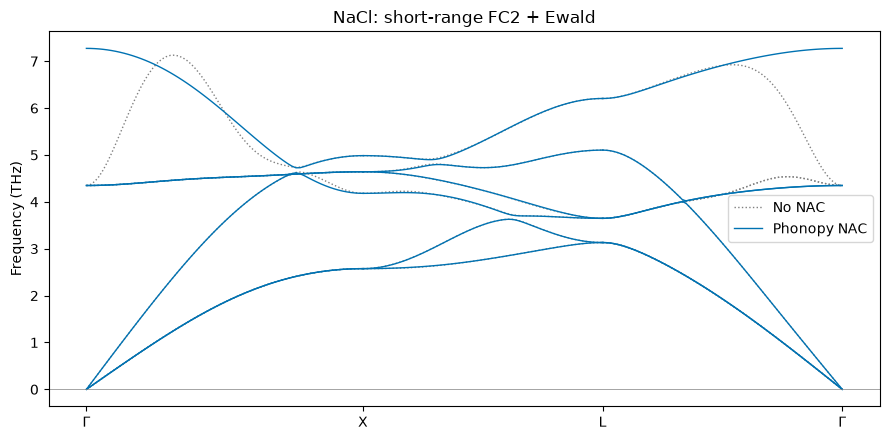

In [9]:
fig, axis = plt.subplots(figsize=(9, 4.5))
for band, color, style, label in (
    (without_nac, "0.5", ":", "No NAC"),
    (with_nac, "#0072B2", "-", "Phonopy NAC"),
):
    for index, (distance, frequencies) in enumerate(zip(band.distances, band.frequencies)):
        lines = axis.plot(distance, frequencies, color=color, linestyle=style, linewidth=1)
        if index == 0:
            lines[0].set_label(label)
ticks = [with_nac.distances[0][0]] + [d[-1] for d in with_nac.distances]
axis.set_xticks(ticks, ["Γ", "X", "L", "Γ"])
axis.axhline(0, color="0.5", linewidth=0.5)
axis.set_ylabel("Frequency (THz)")
axis.set_title("NaCl: short-range FC2 + Ewald")
axis.legend()
fig.tight_layout()
plt.show()

## 接下来

我们从已计算的原子力恢复了短程 FC2，在相同超胞中回加长程项，并用 Phonopy 检查 NAC 的影响。长程力扣除没有截断偶极尾，也没有加入长程 FC3 或 FC4。

换成自己的极性材料，最先替换结构与超胞、带力样本、Born 电荷和电子介电张量，再检查 cutoff 与超胞收敛。接口细节见[长程力处理](../ewald-api.md)，推导见[长程电静力学](../theory/long-range-electrostatics.md)。

下一份[石墨烯与 MoS₂ 教程](rotational-sum-rules.ipynb)讨论平移与旋转条件怎样影响声子谱。